# 3D Metrics

To assess segmentation performance in 3D, we can use metrics from the `vl` (volume) accessor.

**NOTE:** This module is still experimental and will change substantially in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import spatialdata as sd 
import segtraq
import anndata as ad 
import matplotlib.pyplot as plt
import pandas as pd
import spatialdata_plot
import seaborn as sns
import numpy as np
import ovrlpy
from pathlib import Path

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__vers

In [3]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")

In [4]:
sdata_xenium = sd.read_zarr(data_path / "sdata_xenium_crop.zarr")
sdata_proseg = sd.read_zarr(data_path / "proseg_output_v3/sdata_proseg_crop.zarr")

Proseg v3 spatial data output has no qv column! make sure it is filtered at min qv 20

In [5]:
def subset_points(sdata, min_qv=None, points_gene_key="feature_name"):
    pts = sdata.points["transcripts"]

    prefixes = (
        "NegControlProbe_",
        "antisense_",
        "NegControlCodeword",
        "BLANK_",
        "Blank-",
        "NegPrb",
        "DeprecatedCodeword_",
        "Intergenic_Region_",
        "UnassignedCodeword_",
        "Human_",
    )

    if min_qv:
        mask = pts[points_gene_key].str.startswith(prefixes)| (pts["qv"] < min_qv)
    else:
        mask = pts[points_gene_key].str.startswith(prefixes)
    pts_sub = pts[~mask]


    sdata.points["transcripts"] = pts_sub

In [6]:
subset_points(sdata_xenium, min_qv=20)
subset_points(sdata_proseg, points_gene_key="gene")

In [7]:
sdata_xenium

SpatialData object, with associated Zarr store: /g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium/sdata_xenium_crop.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 2500, 2500), (1, 1250, 1250), (1, 625, 625), (1, 313, 313), (1, 156, 156)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1563, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1501, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (1563, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [8]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    shapes_cell_id_key=None,
    nucleus_shapes_cell_id_key=None,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_volume_key="volume",
    tables_cell_id_key="cell",
    shapes_cell_id_key=None,
    nucleus_shapes_cell_id_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    points_x_key="observed_x",
    points_y_key="observed_y",
    points_z_key="observed_z",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: The shapes and tables indices do not match. This will lead to errors when using spatialdata_plot. IDs in shapes index: [76556, 76557, 76558, 76559, 76560]..., IDs in tables index: ['94579', '95569', '76732', '95817', '76977']...
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: The shapes and tables indices do not match. This will lead to errors when using spatialdata_plot. IDs in shapes index: [73918, 73938, 73939, 73940, 73941]..., IDs in tables index: ['70960', '70412', '75333', '70671', '71210']...
  validate_spatialdata(


In [9]:
st_dict = {"xenium": st_xenium, "proseg": st_proseg}

In [10]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

st_xenium.run_label_transfer(
    adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
)

st_proseg.run_label_transfer(
    adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:350: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["raw"]`.
  result = _run_label_transfer(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:420: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata_q.layers["raw"] = adata_q.X
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass 

/tmp/ipykernel_901664/4173000350.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


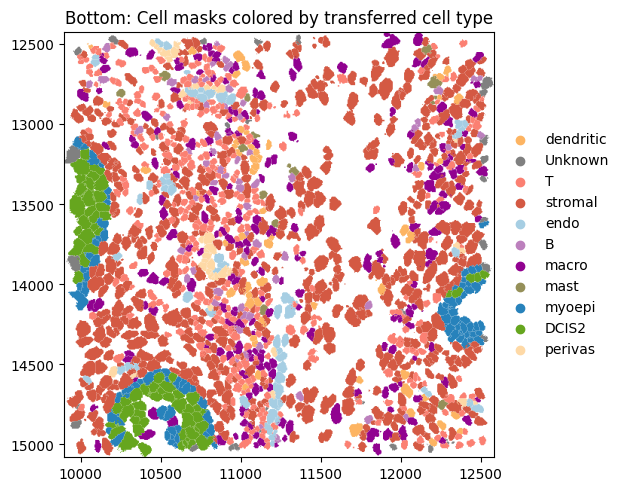

In [11]:
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}


s = st_proseg.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st_proseg.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

# compute per-cell color
labels = st_proseg.sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

st_proseg.sdata.tables["table"].obs["region"] = "cell_boundaries"
st_proseg.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st_proseg.sdata.pl.render_shapes("cell_boundaries", color="transferred_celltype_plot", palette=cols, groups=labels).pl.show(
    title=f"Bottom: Cell masks colored by transferred cell type", coordinate_systems="global"
)

/tmp/ipykernel_901664/3735507103.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


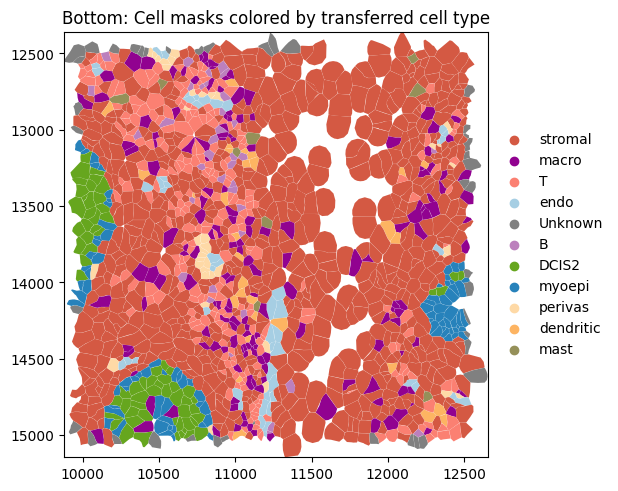

In [12]:
s = st_xenium.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st_xenium.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

# compute per-cell color
labels = st_xenium.sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

st_xenium.sdata.tables["table"].obs["region"] = "cell_boundaries"
st_xenium.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st_xenium.sdata.pl.render_shapes("cell_boundaries", color="transferred_celltype_plot", palette=cols, groups=labels).pl.show(
    title=f"Bottom: Cell masks colored by transferred cell type", coordinate_systems="global"
)

## Cosine similarity between top and bottom z

In [20]:
st_xenium.vl.compute_sim_top_bottom_z()
st_proseg.vl.compute_sim_top_bottom_z()

,cell,cosine_sim_top_bottom_z
0,70066.0,NaN
1,70067.0,NaN
2,70069.0,NaN
3,70070.0,0.618823
4,70071.0,0.107052
...,...,...
1526,76434.0,0.483797
1527,76435.0,0.529427
1528,76436.0,0.178302
1529,76439.0,0.295869


<Axes: xlabel='cosine_sim_top_bottom_z', ylabel='Density'>

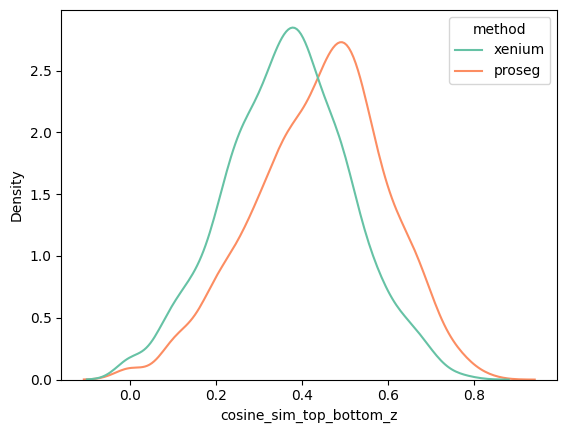

In [21]:
cosine_sim_top_bottom_z = []

df_x = st_xenium.sdata.tables["table"].obs[["cosine_sim_top_bottom_z"]].copy()
df_x["method"] = "xenium"
df_p = st_proseg.sdata.tables["table"].obs[["cosine_sim_top_bottom_z"]].copy()
df_p["method"] = "proseg"

df = pd.concat([df_x, df_p], ignore_index=True)
sns.kdeplot(data=df, x="cosine_sim_top_bottom_z", hue="method", palette="Set2", common_norm=False, fill=False)

In [22]:
def plot_feature_labels(sdata, method, feature, axes, i):
    labels = sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
    cols = [col_celltype[lab] for lab in labels]

    sdata.tables["table"].obs["region"] = "cell_boundaries"
    sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color="transferred_celltype_plot",
        palette=cols,
        groups=labels,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[0, i], title=f"{method}:Cell boundaries colored by cell type", coordinate_systems="global")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=feature,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[1, i], title=f"{method}: {feature}", coordinate_systems="global")

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 94 NaN values in color data. These observations will be colored with the 'na_color'.                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 110 NaN values in color data. These observations will be colored with the 'na_color'.               


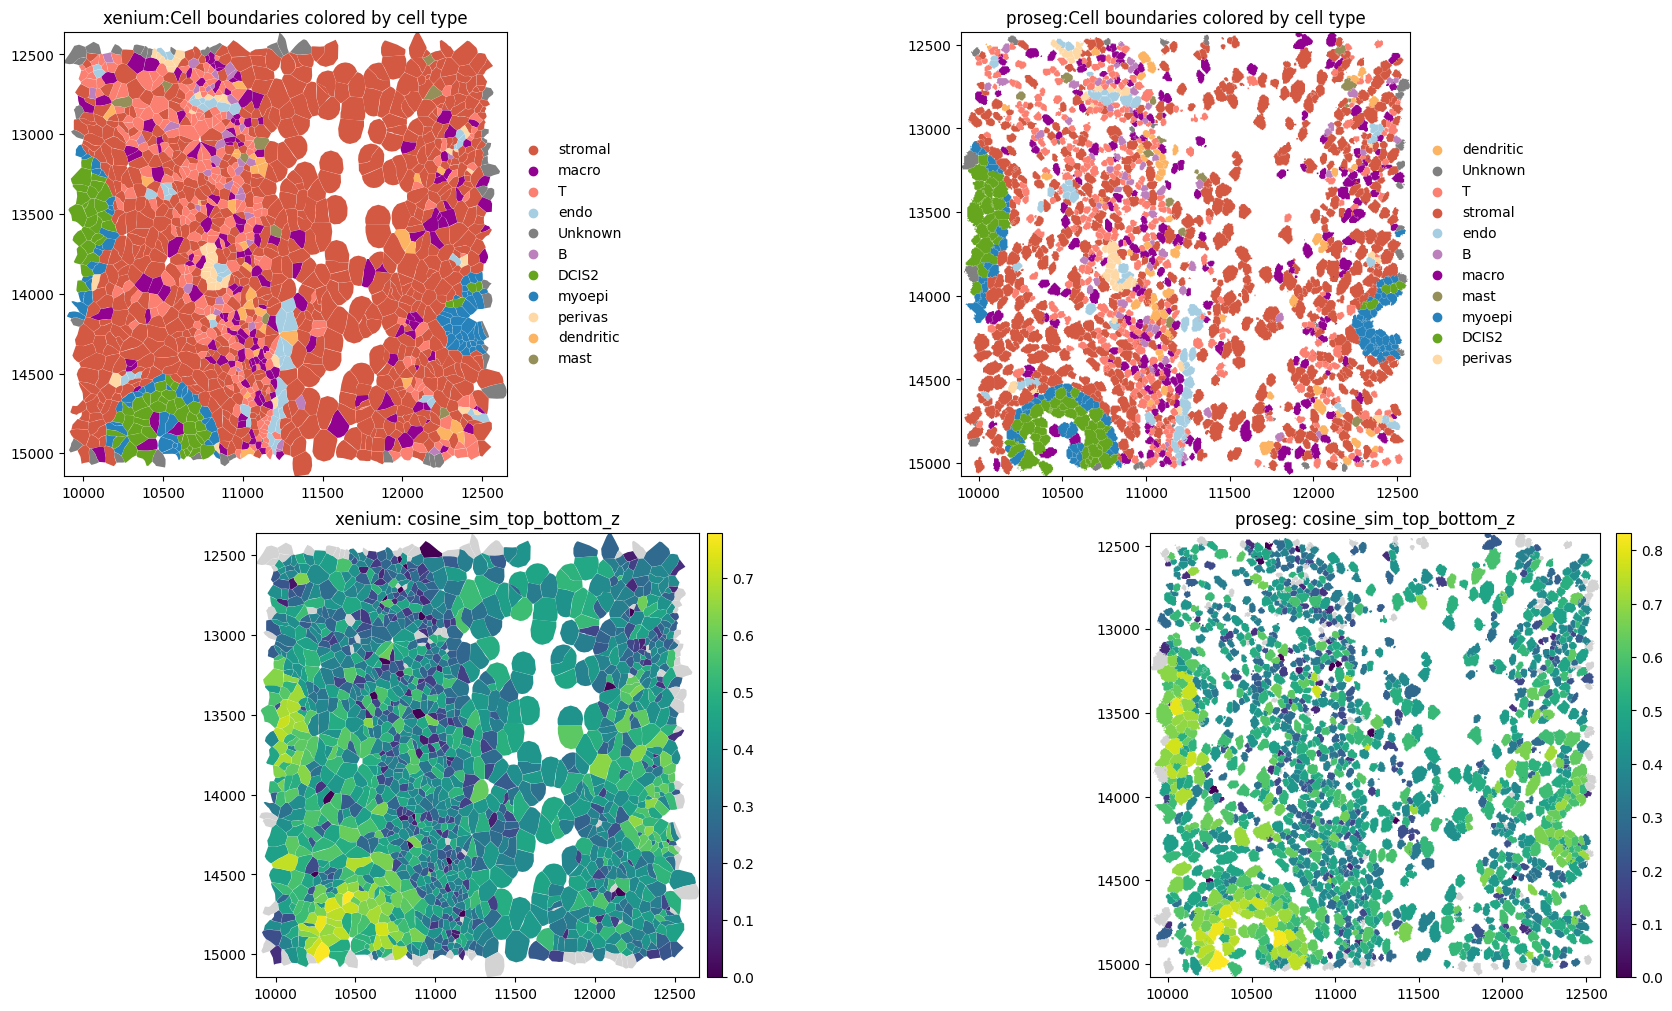

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
axes = np.atleast_2d(axes)
for i, (method, st) in enumerate(st_dict.items()):
    plot_feature_labels(st.sdata, method, "cosine_sim_top_bottom_z", axes, i)

In [23]:
# method for visualization
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()]
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

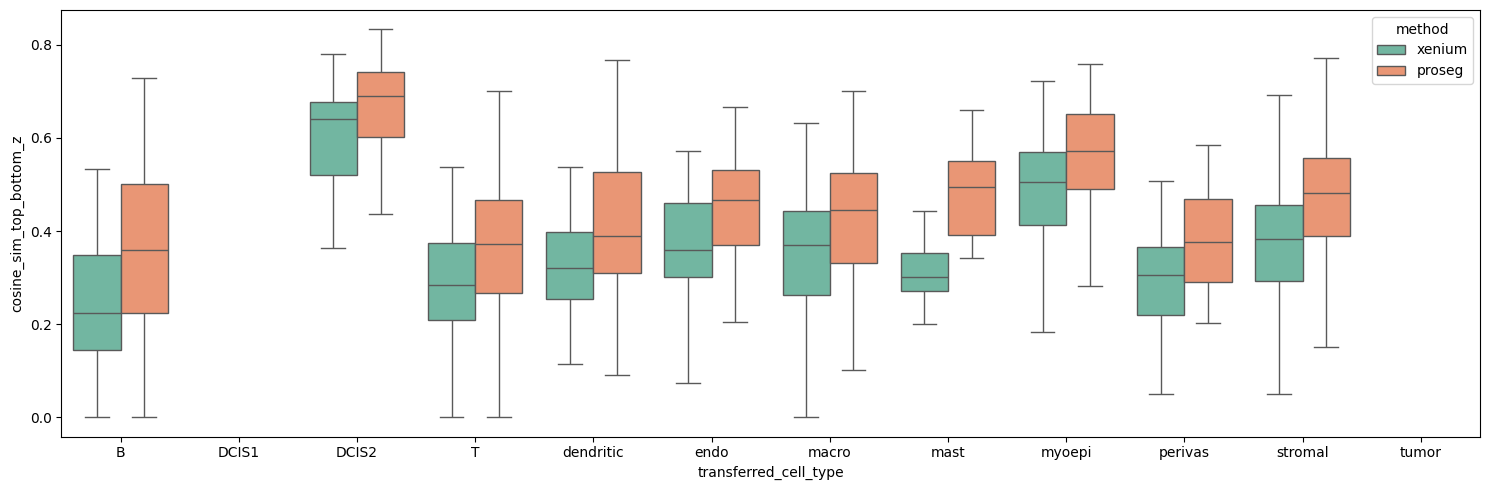

In [24]:
boxplot_per_celltype(st_dict, "cosine_sim_top_bottom_z")

<Axes: xlabel='transcript_count', ylabel='cosine_sim_top_bottom_z'>

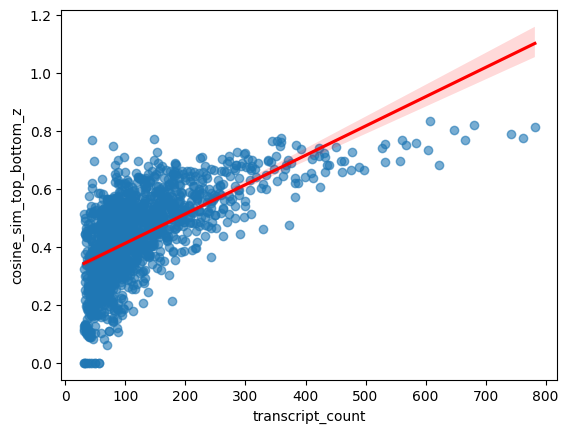

In [41]:
df = sdata_proseg.tables["table"].obs[["transcript_count", "cosine_sim_top_bottom_z"]]
sns.regplot(
    data = df,
    x = "transcript_count",
    y = "cosine_sim_top_bottom_z",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,

)

## Overlap percentage

can only be computed for 3D methods



In [25]:
#st_proseg.vl.compute_heterotypic_overlap_fraction(unknown_policy="exclude")
st_proseg.vl.compute_heterotypic_overlap_fraction()

,cell,heterotypic_overlap_area,heterotypic_overlap_fraction
0,70066,5.0,0.185185
1,70067,0.0,0.000000
2,70069,11.0,0.239130
3,70070,7.0,0.111111
4,70071,0.0,NaN
...,...,...,...
1529,76434,5.0,0.092593
1530,76435,0.0,NaN
1531,76436,0.0,NaN
1532,76439,0.0,NaN


/tmp/ipykernel_901664/53454074.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=df, x="heterotypic_overlap_area", palette="Set2", common_norm=False, fill=False)


<Axes: xlabel='heterotypic_overlap_area', ylabel='Density'>

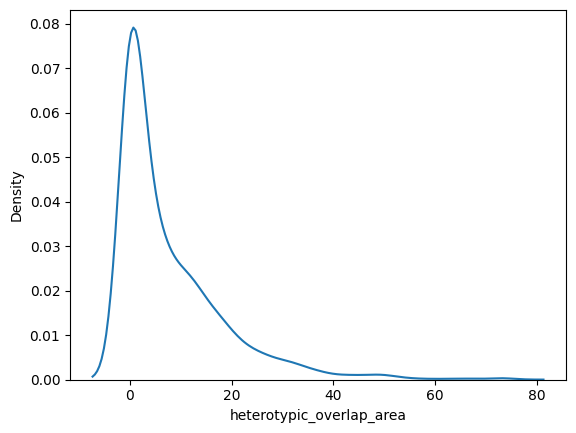

In [26]:
df = st_proseg.sdata.tables["table"].obs[["cell", "heterotypic_overlap_area"]]

sns.kdeplot(data=df, x="heterotypic_overlap_area", palette="Set2", common_norm=False, fill=False)

In [27]:
tbl = sdata_proseg.tables["table"]
rank = 2
idx = tbl.obs["heterotypic_overlap_area"].nlargest(rank).index[rank-1]
tbl.obs.loc[idx, :]

cell                                      71091
original_cell_id                          76847
centroid_x                          2339.791748
centroid_y                          2976.925781
centroid_z                              0.29946
component                                     3
volume                                     69.5
surface_area                              330.0
scale                                       1.0
region                          cell_boundaries
transcript_count                          211.0
gene_count                                 43.0
transferred_cell_type                   stromal
pearson_score                          0.696937
transferred_celltype_plot               stromal
cosine_sim_top_bottom_z                0.583799
heterotypic_overlap_area                   73.0
heterotypic_overlap_fraction            0.51049
Name: 71091, dtype: object

/tmp/ipykernel_901664/1105258059.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  

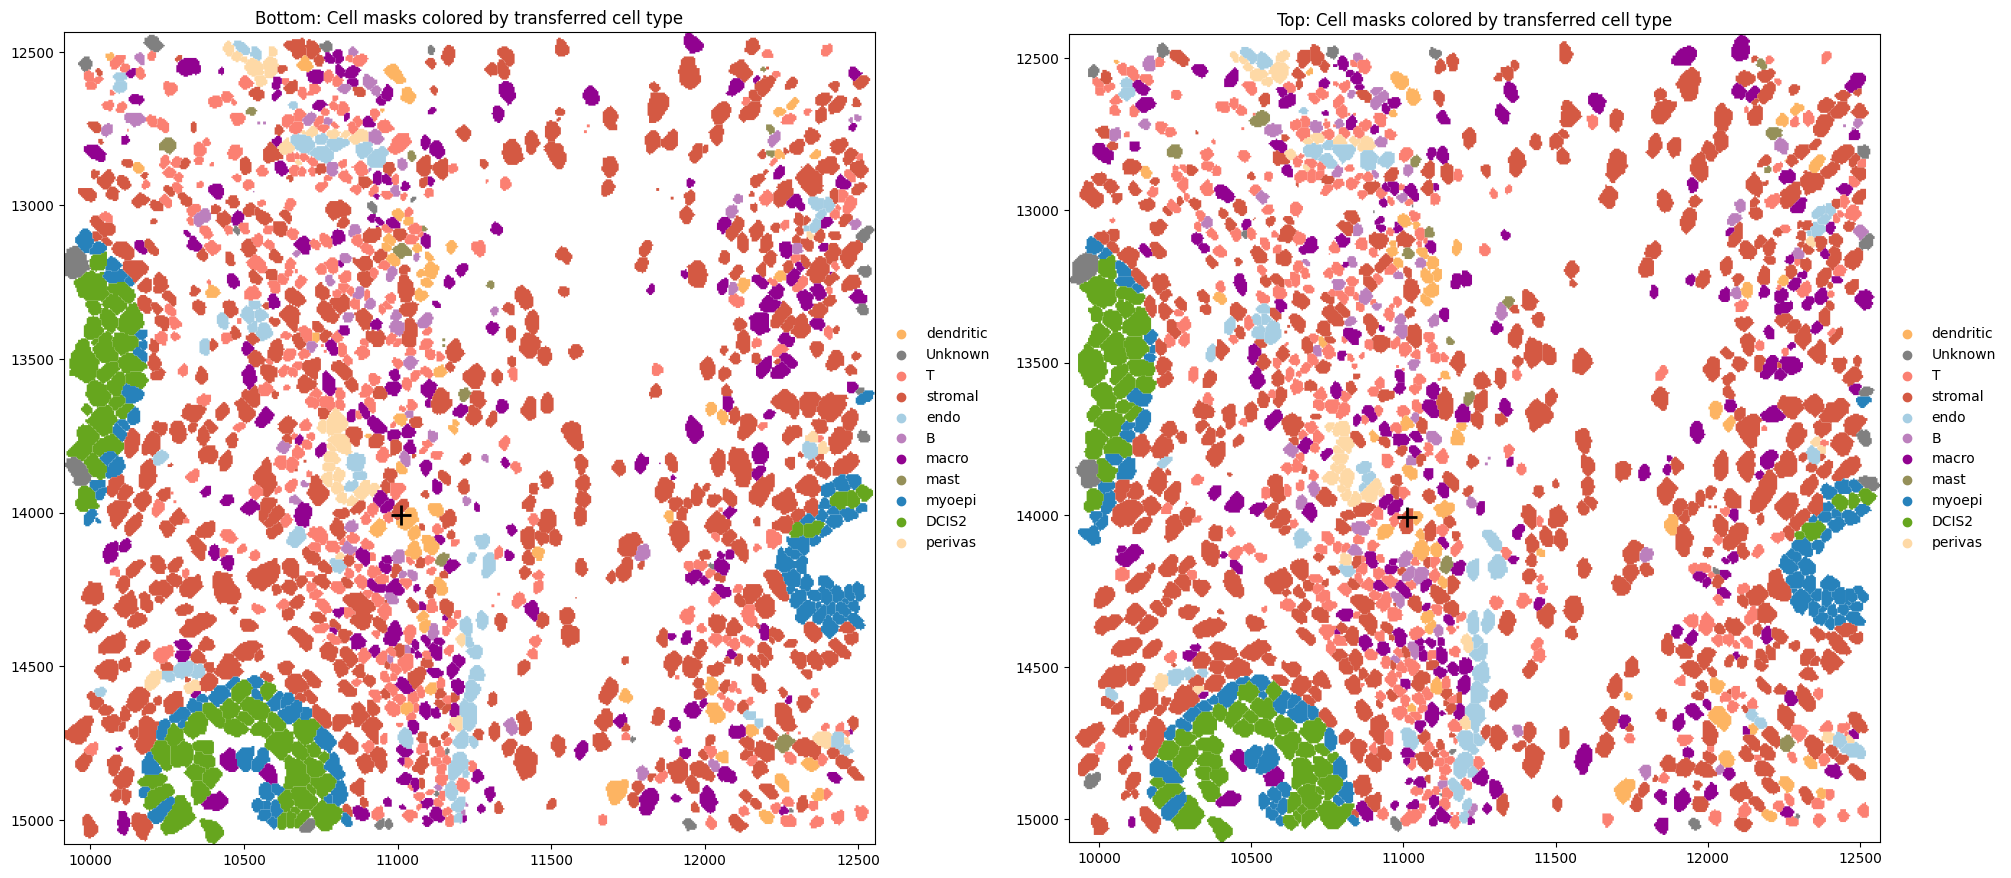

In [28]:
axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)[1].flatten()

tbl = sdata_proseg.tables["table"]
rank = 2
idx = tbl.obs["heterotypic_overlap_area"].nlargest(rank).index[rank-1]
x0, y0 = tbl.obs.loc[idx, "centroid_x"]/0.2125, tbl.obs.loc[idx, "centroid_y"]/0.2125

s = st_proseg.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st_proseg.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

# compute per-cell color
labels = st_proseg.sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

st_proseg.sdata.tables["table"].obs["region"] = "cell_boundaries_z0"
st_proseg.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries_z0")

st_proseg.sdata.pl.render_shapes("cell_boundaries_z0", color="transferred_celltype_plot", palette=cols, groups=labels).pl.show(
    ax=axes[0], title=f"Bottom: Cell masks colored by transferred cell type", coordinate_systems="global"
)

axes[0].scatter([x0], [y0], marker="+", s=200, c="black", linewidths=2, zorder=10)

st_proseg.sdata.tables["table"].obs["region"] = "cell_boundaries_z1"
st_proseg.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries_z1")

st_proseg.sdata.pl.render_shapes("cell_boundaries_z1", color="transferred_celltype_plot", palette=cols, groups=labels).pl.show(
    ax=axes[1], title=f"Top: Cell masks colored by transferred cell type", coordinate_systems="global"
)

axes[1].scatter([x0], [y0], marker="+", s=200, c="black", linewidths=2, zorder=10)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


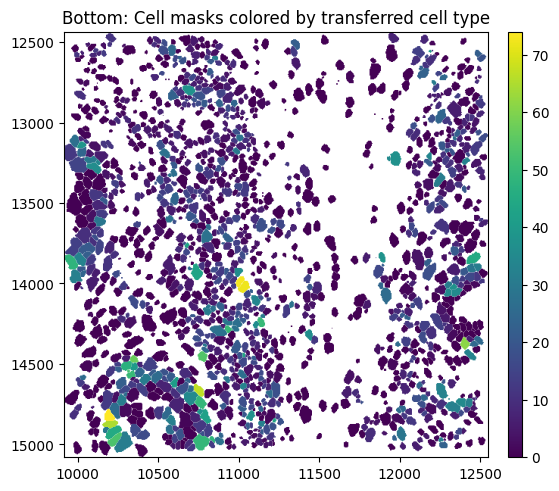

In [30]:
st_proseg.sdata.tables["table"].obs["region"] = "cell_boundaries_z0"
st_proseg.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries_z0")

st_proseg.sdata.pl.render_shapes("cell_boundaries_z0", color="heterotypic_overlap_area").pl.show(
    title=f"Bottom: Cell masks colored by transferred cell type", coordinate_systems="global"
)

## Ovrlpy

proseg changes changed the z coordinates - they are between 0 and 1

/tmp/ipykernel_1432923/3924031128.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


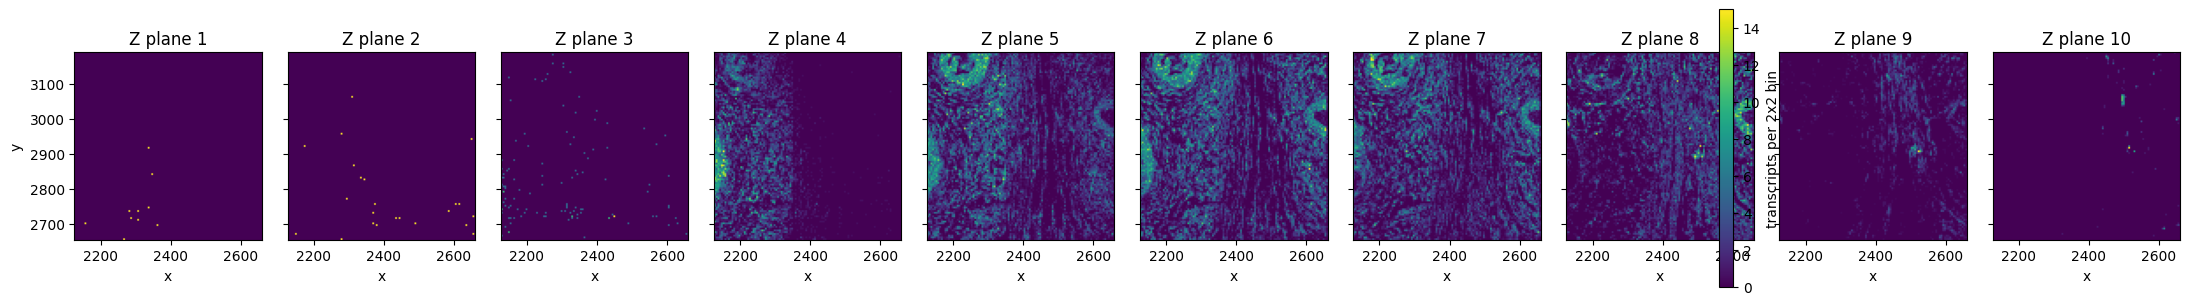

In [91]:
prefixes = (
    "NegControlProbe_",
    "antisense_",
    "NegControlCodeword_",
    "BLANK_",
    "Blank-",
    "NegPrb",
    "DeprecatedCodeword_",
    "Intergenic_Region_",
    "UnassignedCodeword_",
)

# Load + filter
df = sdata_xenium["transcripts"].compute()
df = df[~df["feature_name"].str.startswith(prefixes)]

# --- bin into 5 z-planes ---
df["z_bin"] = pd.cut(df["z"], bins=10, labels=False)

# --- 2x2 binning in x/y (counts per 2x2 "pixel") ---
bin_size = 5.0  # spatial units; if your coordinates are already in pixels, this is "2x2 pixels"
df["x_bin"] = (df["x"] / bin_size).astype(int)
df["y_bin"] = (df["y"] / bin_size).astype(int)

# establish common grid across all planes so axes align
x_minb, x_maxb = df["x_bin"].min(), df["x_bin"].max()
y_minb, y_maxb = df["y_bin"].min(), df["y_bin"].max()
nx = x_maxb - x_minb + 1
ny = y_maxb - y_minb + 1

num_planes = int(df["z_bin"].nunique())

# plot (1x5)
fig, axes = plt.subplots(1, 10, figsize=(22, 4), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for i in range(10):
    ax = axes[i]

    plane = df[df["z_bin"] == i]
    # counts per (x_bin, y_bin)
    counts = (
        plane.groupby(["y_bin", "x_bin"])
             .size()
             .reindex(pd.MultiIndex.from_product(
                 [range(y_minb, y_maxb + 1), range(x_minb, x_maxb + 1)],
                 names=["y_bin", "x_bin"]
             ), fill_value=0)
             .values
             .reshape(ny, nx)
    )

    # show density image; extent puts it back into x/y coordinates
    im = ax.imshow(
        counts,
        origin="lower",
        aspect="equal",
        extent=[
            x_minb * bin_size, (x_maxb + 1) * bin_size,
            y_minb * bin_size, (y_maxb + 1) * bin_size,
        ],
    )
    ax.set_title(f"Z plane {i+1}")
    ax.set_xlabel("x")
    if i == 0:
        ax.set_ylabel("y")

# one colorbar for all
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("transcripts per 2x2 bin")

plt.tight_layout()
plt.show()


/tmp/ipykernel_1432923/1978644760.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


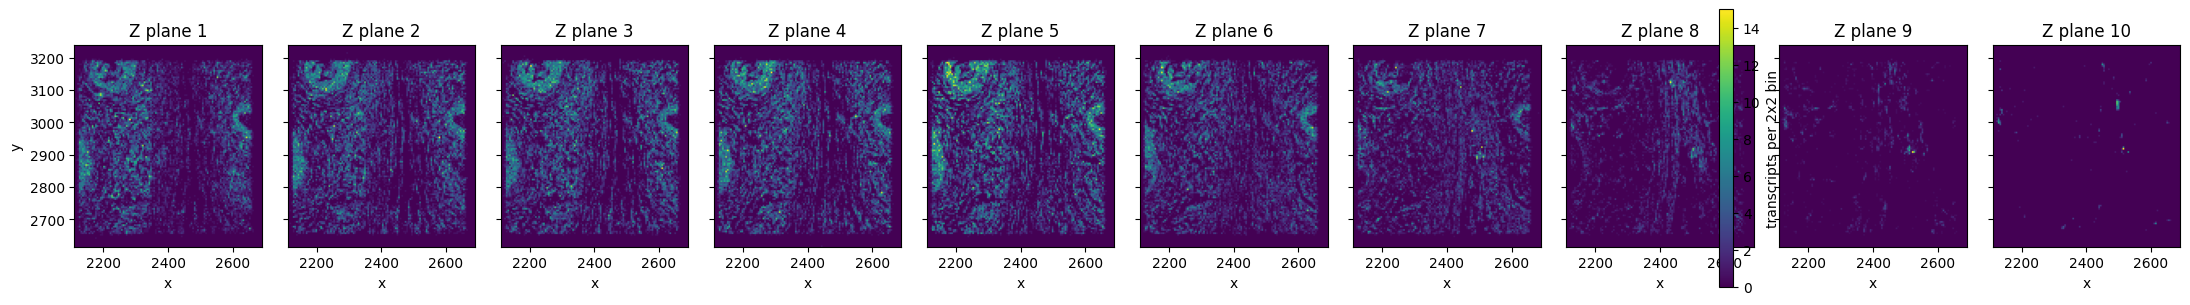

In [98]:
prefixes = (
    "NegControlProbe_",
    "antisense_",
    "NegControlCodeword_",
    "BLANK_",
    "Blank-",
    "NegPrb",
    "DeprecatedCodeword_",
    "Intergenic_Region_",
    "UnassignedCodeword_",
)

# Load + filter
df = sdata_proseg["transcripts"].compute()
df = df[~df["gene"].str.startswith(prefixes)]

# --- bin into 5 z-planes ---
df["z_bin"] = pd.cut(df["observed_z"], bins=10, labels=False)

# --- 2x2 binning in x/y (counts per 2x2 "pixel") ---
bin_size = 5.0  # spatial units; if your coordinates are already in pixels, this is "2x2 pixels"
df["x_bin"] = (df["observed_x"] / bin_size).astype(int)
df["y_bin"] = (df["observed_y"] / bin_size).astype(int)

# establish common grid across all planes so axes align
x_minb, x_maxb = df["x_bin"].min(), df["x_bin"].max()
y_minb, y_maxb = df["y_bin"].min(), df["y_bin"].max()
nx = x_maxb - x_minb + 1
ny = y_maxb - y_minb + 1

num_planes = int(df["z_bin"].nunique())

# plot (1x5)
fig, axes = plt.subplots(1, 10, figsize=(22, 4), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for i in range(10):
    ax = axes[i]

    plane = df[df["z_bin"] == i]
    # counts per (x_bin, y_bin)
    counts = (
        plane.groupby(["y_bin", "x_bin"])
             .size()
             .reindex(pd.MultiIndex.from_product(
                 [range(y_minb, y_maxb + 1), range(x_minb, x_maxb + 1)],
                 names=["y_bin", "x_bin"]
             ), fill_value=0)
             .values
             .reshape(ny, nx)
    )

    # show density image; extent puts it back into x/y coordinates
    im = ax.imshow(
        counts,
        origin="lower",
        aspect="equal",
        extent=[
            x_minb * bin_size, (x_maxb + 1) * bin_size,
            y_minb * bin_size, (y_maxb + 1) * bin_size,
        ],
    )
    ax.set_title(f"Z plane {i+1}")
    ax.set_xlabel("x")
    if i == 0:
        ax.set_ylabel("y")

# one colorbar for all
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("transcripts per 2x2 bin")

plt.tight_layout()
plt.show()


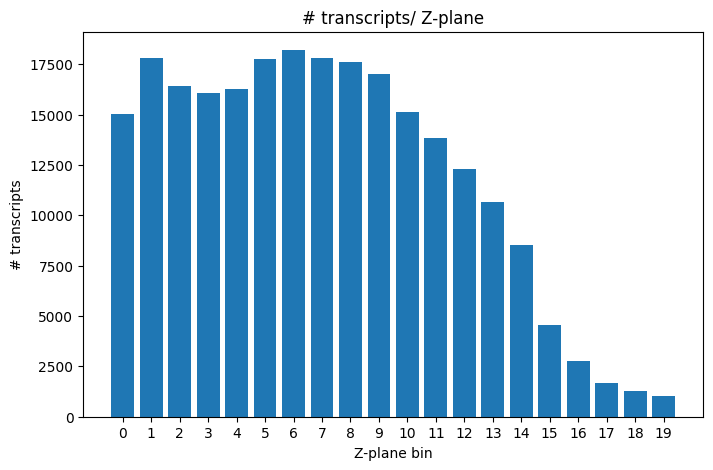

In [94]:
df["z_bin_20"] = pd.cut(df["z"], bins=20, labels=False)

counts = df["z_bin_20"].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, width=0.8)
plt.xlabel("Z-plane bin")
plt.ylabel("# transcripts")
plt.title("# transcripts/ Z-plane")
plt.xticks(counts.index)
plt.show()

In [31]:
coordinate_df = sdata_xenium["transcripts"].compute()
coordinate_df = coordinate_df.rename(columns={"feature_name": "gene"})  
coordinate_df = coordinate_df[["gene", "x", "y", "z"]] 
coordinate_df["z"] = coordinate_df["z"] - coordinate_df["z"].min()

In [32]:
ovrlpy_sdata = ovrlpy.Ovrlp(coordinate_df, n_components=10, min_distance=7, n_workers=8, random_state=42)
ovrlpy_sdata.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 571 pseudocells
sampling expression:


100%|██████████| 1/1 [00:00<00:00,  2.37it/s]


Modeling 10 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 4/4 [00:03<00:00,  1.16it/s]


In [33]:
st_xenium.vl.compute_mean_vsi_per_cell(ovrlpy_sdata.integrity_map)

,cell_id,mean_vsi
0,6327,0.699027
1,6328,0.622374
2,6330,0.633132
3,6331,0.726122
4,6332,0.726925
...,...,...
1544,95953,0.891320
1545,95954,0.195624
1546,95955,0.845207
1547,95959,0.576550


WARNING  Found 14 NaN values in color data. These observations will be colored with the 'na_color'.                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


WARNING  Found 94 NaN values in color data. These observations will be colored with the 'na_color'.                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


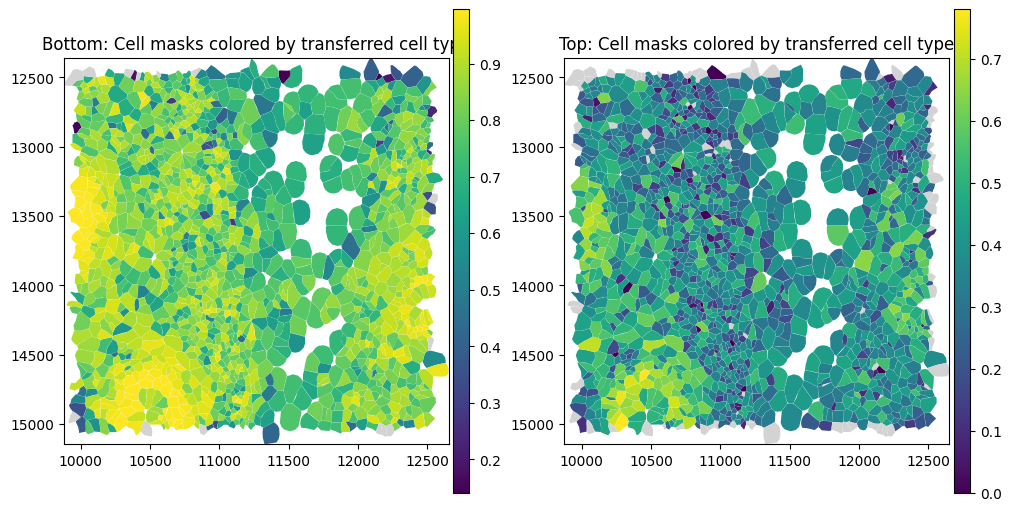

In [34]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()
st_xenium.sdata.tables["table"].obs["region"] = "cell_boundaries"
st_xenium.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st_xenium.sdata.pl.render_shapes("cell_boundaries", color="mean_vsi").pl.show(
    ax=axes[0], title=f"Bottom: Cell masks colored by transferred cell type", coordinate_systems="global"
)

st_xenium.sdata.tables["table"].obs["region"] = "cell_boundaries"
st_xenium.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st_xenium.sdata.pl.render_shapes("cell_boundaries", color="cosine_sim_top_bottom_z").pl.show(
    ax=axes[1], title=f"Top: Cell masks colored by transferred cell type", coordinate_systems="global"
)

<Axes: xlabel='mean_vsi', ylabel='cosine_sim_top_bottom_z'>

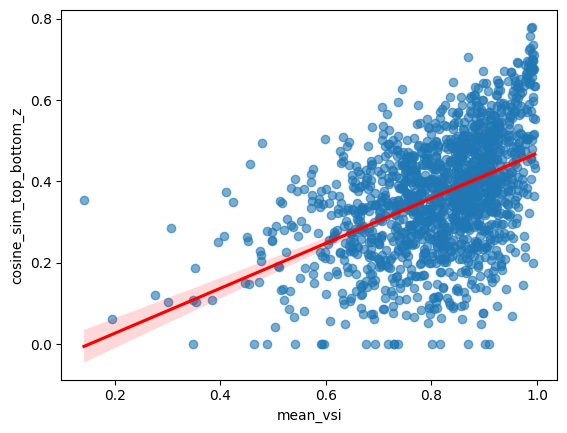

In [36]:
df = sdata_xenium.tables["table"].obs[["mean_vsi", "cosine_sim_top_bottom_z"]]
sns.regplot(
    data = df,
    x = "mean_vsi",
    y = "cosine_sim_top_bottom_z",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,

)

In [63]:
coordinate_df = sdata_proseg["transcripts"].compute()
coordinate_df = coordinate_df[["gene", "observed_x", "observed_y", "observed_z"]] 
coordinate_df = coordinate_df.rename(columns={"observed_x": "x", "observed_y":"y", "observed_z":"z"})
coordinate_df["z"] = coordinate_df["z"] - coordinate_df["z"].min()

In [64]:
ovrlpy_sdata = ovrlpy.Ovrlp(coordinate_df, n_components=10, min_distance=7, n_workers=8, random_state=42)
ovrlpy_sdata.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 540 pseudocells
sampling expression:


100%|██████████| 1/1 [00:00<00:00,  2.77it/s]


Modeling 10 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 4/4 [00:03<00:00,  1.18it/s]


In [65]:
st_proseg.vl.compute_mean_vsi_per_cell(ovrlpy_sdata.integrity_map)

round


,cell,mean_vsi
0,70066.0,0.000000
1,70067.0,0.000000
2,70069.0,0.000000
3,70070.0,0.000000
4,70071.0,0.010480
...,...,...
1526,76434.0,0.865753
1527,76435.0,0.746226
1528,76436.0,0.773668
1529,76439.0,0.638048


WARNING  Found 2 NaN values in color data. These observations will be colored with the 'na_color'.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


WARNING  Found 110 NaN values in color data. These observations will be colored with the 'na_color'.               


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


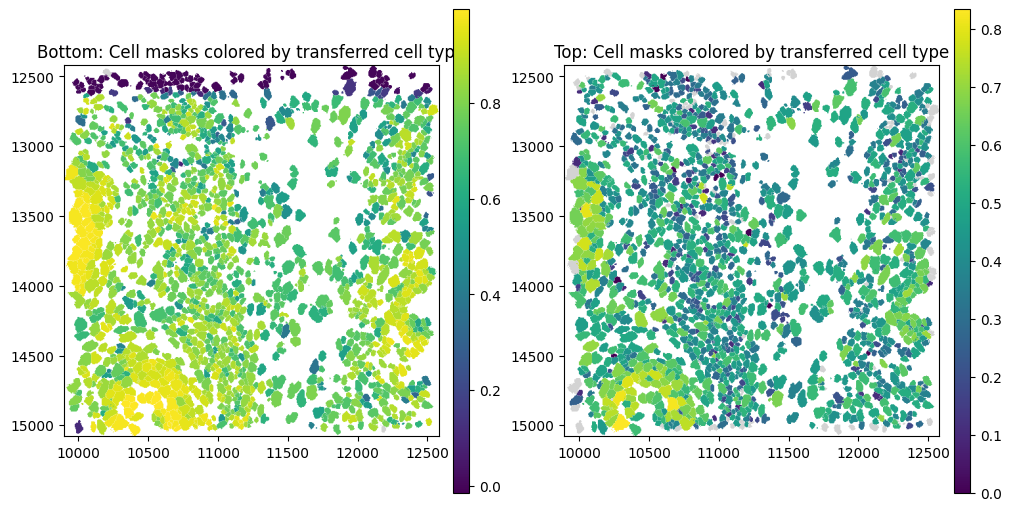

In [66]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()
st_proseg.sdata.tables["table"].obs["region"] = "cell_boundaries"
st_proseg.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st_proseg.sdata.pl.render_shapes("cell_boundaries", color="mean_vsi").pl.show(
    ax=axes[0], title=f"Bottom: Cell masks colored by transferred cell type", coordinate_systems="global"
)

st_proseg.sdata.tables["table"].obs["region"] = "cell_boundaries"
st_proseg.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

st_proseg.sdata.pl.render_shapes("cell_boundaries", color="cosine_sim_top_bottom_z").pl.show(
    ax=axes[1], title=f"Top: Cell masks colored by transferred cell type", coordinate_systems="global"
)

above something is off...

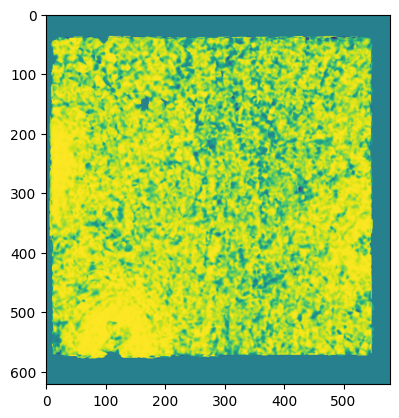

In [69]:
plt.imshow(ovrlpy_sdata.integrity_map)

<Axes: xlabel='mean_vsi', ylabel='cosine_sim_top_bottom_z'>

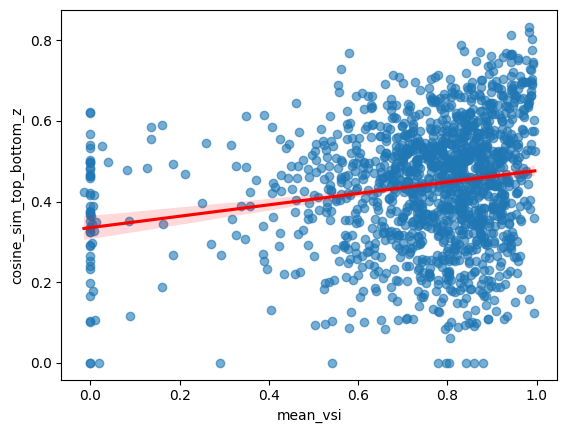

In [74]:
df = sdata_proseg.tables["table"].obs[["mean_vsi", "cosine_sim_top_bottom_z"]]
sns.regplot(
    data = df,
    x = "mean_vsi",
    y = "cosine_sim_top_bottom_z",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,

)

<Axes: xlabel='mean_vsi', ylabel='heterotypic_overlap_area'>

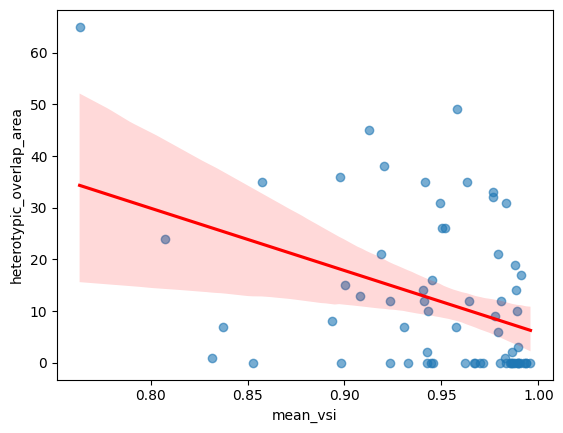

In [80]:
df = sdata_proseg.tables["table"].obs.loc[sdata_proseg.tables["table"].obs["transferred_cell_type"]=="DCIS2",["mean_vsi", "heterotypic_overlap_area"]]
sns.regplot(
    data = df,
    x = "mean_vsi",
    y = "heterotypic_overlap_area",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,

)

In [70]:
ovrlpy_sdata.integrity_map

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(622, 578), dtype=float32)

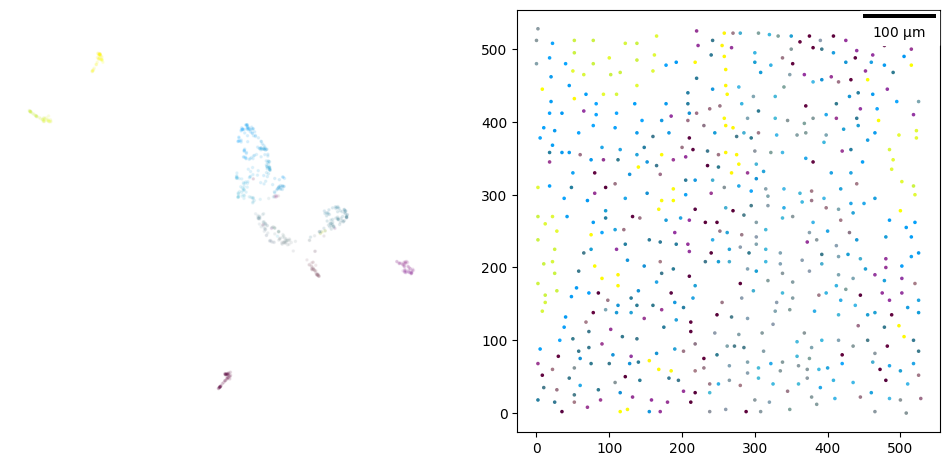

In [108]:
fig = ovrlpy.plot_pseudocells(ovrlpy_sdata, umap_kwargs={"scatter_kwargs":{"s":10}}, tissue_kwargs={"s":10})

In [109]:
X = adata_ref.X.toarray()

expr = pd.DataFrame(
    X,
    index=adata_ref.obs_names,
    columns=adata_ref.var_names,
)

sig = expr.groupby(adata_ref.obs["celltype_major"]).mean()
sig = sig.loc[:, sig.columns.isin(ovrlpy_sdata.genes)]
sig.index.name = "celltype"

sig.head()

/tmp/ipykernel_1432923/4267525879.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = expr.groupby(adata_ref.obs["celltype_major"]).mean()


,FBLIM1,C1QA,C1QC,TRAPPC3,SMAP2,TACSTD2,CTH,CLCA2,TENT5C,RORC,...,APOBEC3A,APOBEC3B,SERHL2,FBLN1,IL3RA,SMS,FOXP3,AR,IL2RG,TCEAL7
celltype,,,,,,,,,,,,,,,,,,,,,
B,0.009309,0.207284,0.171689,0.273256,0.776709,0.368282,0.020451,0.002083,0.518100,0.030577,...,0.000000,0.0,0.084067,0.101965,0.016217,0.191330,0.021525,0.269874,0.727840,0.002168
DCIS1,0.041266,0.151704,0.133197,0.493650,0.258002,1.836614,0.024996,0.015475,0.222252,0.083117,...,0.001003,0.0,0.186061,0.084057,0.004890,0.466441,0.017596,0.672789,0.088206,0.002712
DCIS2,0.012340,0.128631,0.130720,0.410258,0.168024,1.677000,0.017218,0.027879,0.675662,0.133382,...,0.000495,0.0,0.343311,0.060079,0.004398,0.430267,0.015980,0.895202,0.055265,0.003118
T,0.005459,0.119028,0.101920,0.217819,0.604529,0.167393,0.004340,0.002080,0.151135,0.086075,...,0.000191,0.0,0.021251,0.031918,0.004196,0.136165,0.103967,0.086954,1.381820,0.002532
dendritic,0.011524,0.162531,0.153412,0.362580,0.743494,0.333807,0.005570,0.018729,0.182208,0.028269,...,0.003735,0.0,0.072047,0.095491,1.402497,0.217293,0.020203,0.227327,0.937130,0.006744


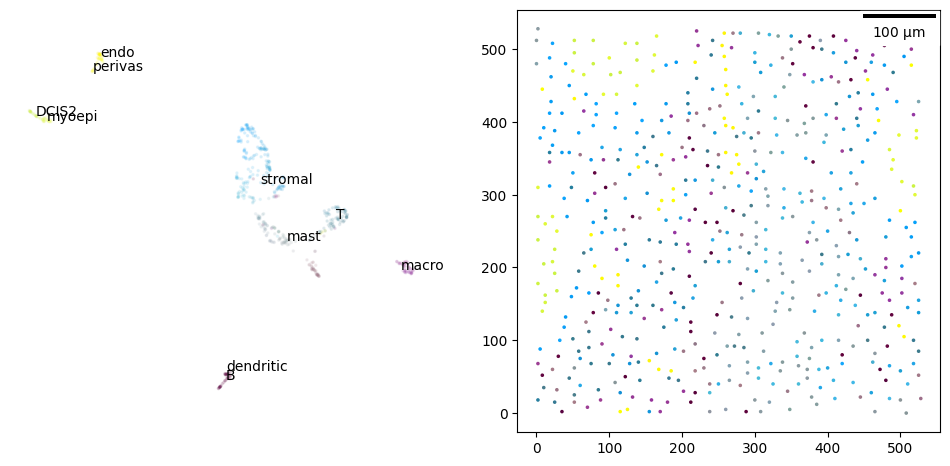

In [111]:
ovrlpy_sdata.fit_signatures(sig)
_ = ovrlpy.plot_pseudocells(ovrlpy_sdata, umap_kwargs={"scatter_kwargs":{"s":10}}, tissue_kwargs={"s":10})

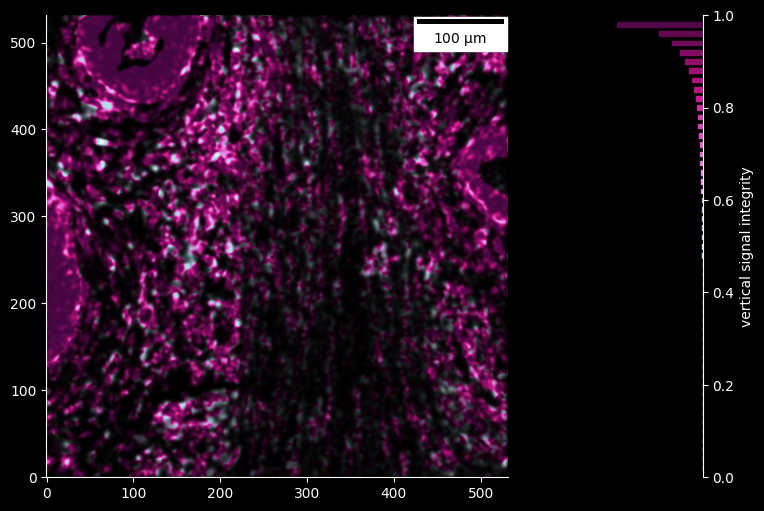

In [112]:
fig = ovrlpy.plot_signal_integrity(ovrlpy_sdata, signal_threshold=1.5) 

In [113]:
doublets = ovrlpy_sdata.detect_doublets(min_signal=1, integrity_sigma=2, min_integrity=0.7)

In [114]:
doublets.to_pandas().sort_values("x")

,x,y,integrity,signal
41,0,337,0.479703,1.407711
113,1,84,0.597671,1.014637
96,11,453,0.565196,1.405911
57,16,482,0.510720,1.007988
28,22,38,0.446397,1.060843
...,...,...,...,...
55,515,94,0.508049,1.004336
45,524,116,0.484955,1.036700
140,525,427,0.626476,1.000934
163,527,74,0.651288,1.293299


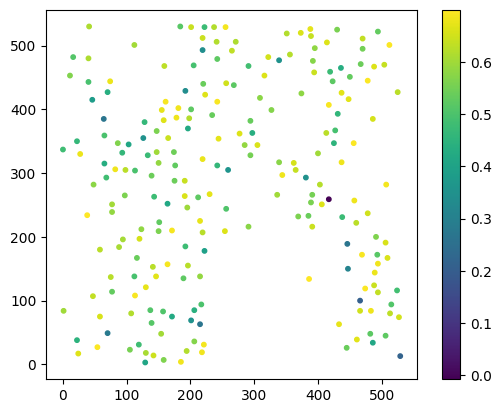

In [115]:
fig, ax = plt.subplots()
_scatter = ax.scatter(
    doublets["x"], doublets["y"], c=doublets["integrity"], s=10, cmap="viridis"
)
_ = ax.set_aspect("equal")
_ = fig.colorbar(_scatter, ax=ax)

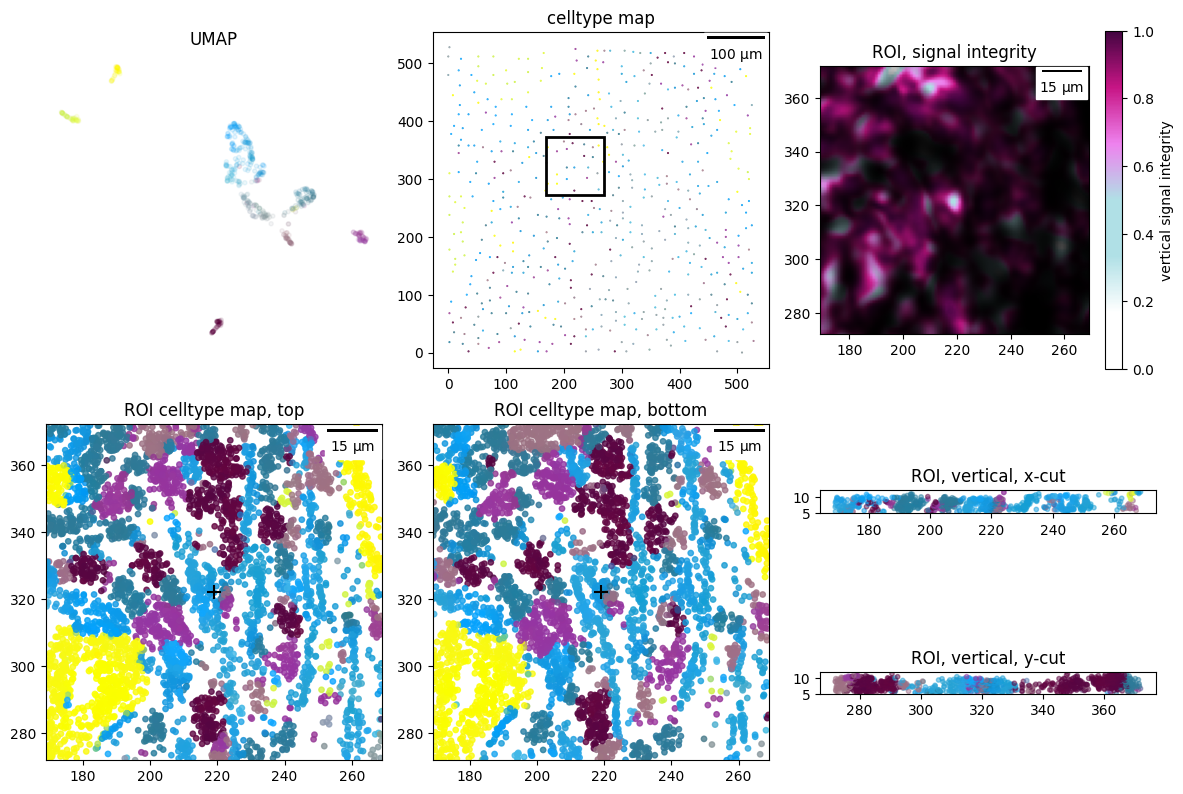

In [125]:
# Which doublet do you want to visualize?
doublet_to_show = 194

x, y = doublets["x", "y"].row(doublet_to_show)

fig = ovrlpy.plot_region_of_interest(ovrlpy_sdata, x, y, window_size=50)